In [55]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [56]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE_BASE = '/content/drive/MyDrive/TrafficAI'
for sub in ['models','results','videos','images']:
    os.makedirs(f'{DRIVE_BASE}/{sub}', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
!pip install -q ultralytics opencv-python "fast-plate-ocr[onnx]" numpy pillow matplotlib tqdm

In [58]:
MODEL_DIR = f'{DRIVE_BASE}/models'
required = ['license_plate_detector.pt', 'yolov8n.pt', 'vehicle_color_n_cls.pt', 'helmet.pt', 'traffic_light.pt']
missing = [m for m in required if not os.path.exists(f'{MODEL_DIR}/{m}')]
if 'yolov8n.pt' in missing:
    from ultralytics import YOLO
    YOLO('yolov8n.pt')
    import shutil
    shutil.move('yolov8n.pt', f'{MODEL_DIR}/yolov8n.pt')
    missing.remove('yolov8n.pt')
if missing:
    print(f'Missing: {missing}')
    print(f'Upload to: {MODEL_DIR}/')
else:
    print('All models ready')

All models ready


In [59]:
!ls "/content/drive/MyDrive/TrafficAI/models"

helmet.pt		   traffic_light.pt	   yolov8n-cls.pt
license_plate_detector.pt  vehicle_color_n_cls.pt  yolov8n.pt


In [60]:
import cv2, numpy as np, time, re, os, base64
from datetime import datetime
from tqdm.notebook import tqdm
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
from ultralytics import YOLO
from fast_plate_ocr import LicensePlateRecognizer as FastPlateOCR
from google.colab import files, output

yolo_plate = YOLO(f'{MODEL_DIR}/license_plate_detector.pt')
yolo_vehicle = YOLO(f'{MODEL_DIR}/yolov8n.pt')

try:
    color_model = YOLO(f'{MODEL_DIR}/vehicle_color_n_cls.pt')
except:
    color_model = None

try:
    helmet_model = YOLO(f'{MODEL_DIR}/helmet.pt')
except:
    helmet_model = None

try:
    light_model = YOLO(f'{MODEL_DIR}/traffic_light.pt')
except:
    light_model = None

ocr = FastPlateOCR(hub_ocr_model='cct-s-v2-global-model', device='auto')

In [62]:
# ==========================================
# CẤU HÌNH HỆ THỐNG
# ==========================================
import ipywidgets as widgets
from IPython.display import display

# Tạo các widget cấu hình
print("⚙️ CẤU HÌNH HỆ THỐNG PHÁT HIỆN VI PHẠM")
print("="*70)

# Checkbox cho các chế độ phát hiện
enable_violation_detection = widgets.Checkbox(
    value=True,
    description='Enable violation detection',
    style={'description_width': 'initial'}
)

enable_red_light = widgets.Checkbox(
    value=True,
    description='🚦 Enable red light violation detection',
    style={'description_width': 'initial'}
)

enable_speed_violation = widgets.Checkbox(
    value=True,
    description='⚡ Enable speed violation detection',
    style={'description_width': 'initial'}
)

show_zones = widgets.Checkbox(
    value=True,
    description='🗺️ Show zones (Waiting/Stop/Intersection)',
    style={'description_width': 'initial'}
)

# Slider cho ngưỡng phát hiện
general_threshold = widgets.FloatSlider(
    value=0.15,
    min=0.05,
    max=0.50,
    step=0.05,
    description='General violation threshold:',
    style={'description_width': 'initial'},
    readout_format='.0%'
)

more_than_two_threshold = widgets.FloatSlider(
    value=0.50,
    min=0.25,
    max=0.75,
    step=0.05,
    description='Carrying more than 2 people:',
    style={'description_width': 'initial'},
    readout_format='.0%'
)

helmet_threshold = widgets.FloatSlider(
    value=0.15,
    min=0.05,
    max=0.50,
    step=0.05,
    description='No helmet:',
    style={'description_width': 'initial'},
    readout_format='.0%'
)

phone_threshold = widgets.FloatSlider(
    value=0.15,
    min=0.05,
    max=0.50,
    step=0.05,
    description='Using phone:',
    style={'description_width': 'initial'},
    readout_format='.0%'
)

# Slider cho tốc độ
speed_limit = widgets.IntSlider(
    value=60,
    min=20,
    max=120,
    step=5,
    description='Speed limit:',
    style={'description_width': 'initial'}
)

# Dropdown cho hướng camera
camera_direction = widgets.Dropdown(
    value='overhead',
    options=['overhead', 'side', 'front', 'back'],
    description='Camera direction:',
    style={'description_width': 'initial'}
)

# Hiển thị tất cả các widget
display(widgets.VBox([
    widgets.HTML("<h3>⚙️ Processing Configuration</h3>"),
    enable_violation_detection,
    widgets.HTML("<hr>"),
    widgets.HTML("<h4>Violation Thresholds</h4>"),
    general_threshold,
    more_than_two_threshold,
    helmet_threshold,
    phone_threshold,
    widgets.HTML("<hr>"),
    widgets.HTML("<h4>Detection Options</h4>"),
    enable_red_light,
    enable_speed_violation,
    widgets.HTML("<hr>"),
    widgets.HTML("<h4>Speed Configuration</h4>"),
    speed_limit,
    widgets.HTML("<hr>"),
    widgets.HTML("<h4>Camera & Display</h4>"),
    camera_direction,
    show_zones
]))

# Lưu cấu hình vào biến toàn cục
CONFIG = {
    'enable_violation_detection': enable_violation_detection,
    'enable_red_light': enable_red_light,
    'enable_speed_violation': enable_speed_violation,
    'show_zones': show_zones,
    'general_threshold': general_threshold,
    'more_than_two_threshold': more_than_two_threshold,
    'helmet_threshold': helmet_threshold,
    'phone_threshold': phone_threshold,
    'speed_limit': speed_limit,
    'camera_direction': camera_direction
}

print("\n✅ Cấu hình đã sẵn sàng! Bạn có thể điều chỉnh các thông số ở trên.")
print("💡 Mẹo: Thay đổi giá trị và chạy cell này để cập nhật cấu hình.")

⚙️ CẤU HÌNH HỆ THỐNG PHÁT HIỆN VI PHẠM



✅ Cấu hình đã sẵn sàng! Bạn có thể điều chỉnh các thông số ở trên.
💡 Mẹo: Thay đổi giá trị và chạy cell này để cập nhật cấu hình.


In [63]:
COLOR_NAMES = ['beige','black','blue','brown','gold','green','grey','orange','pink','purple','red','silver','tan','white','yellow']
VEHICLE_CLASSES = {2:'car', 3:'motorcycle', 5:'bus', 7:'truck'}
VIOLATION_COLORS = {
    'RED_LIGHT': (0, 0, 255),
    'MORE_THAN_TWO_PERSONS': (0, 165, 255),
    'WITHOUT_HELMET': (0, 165, 255),
    'USING_MOBILE': (255, 0, 255),
    'SPEED_VIOLATION': (128, 0, 128)
}

In [65]:
def crop_vehicle_context(image, bbox, vehicle_type):
    x1,y1,x2,y2 = bbox; h,w = image.shape[:2]
    wi,he = max(1,x2-x1), max(1,y2-y1)
    if vehicle_type=='motorcycle': pl,pr,pt,pb = int(wi*0.45),int(wi*0.45),int(he*1.20),int(he*0.25)
    else: pl=pr=pt=pb=0
    return image[max(0,y1-pt):min(h,y2+pb), max(0,x1-pl):min(w,x2+pr)], (max(0,x1-pl),max(0,y1-pt),min(w,x2+pr),min(h,y2+pb))

def detect_vehicles(image, conf=0.25):
    results = yolo_vehicle.predict(image, device=DEVICE, classes=list(VEHICLE_CLASSES.keys()), conf=conf)[0]
    vehicles = []
    if results.boxes is None: return vehicles
    for box in results.boxes:
        x1,y1,x2,y2 = map(int,box.xyxy[0]); cid,cv = int(box.cls[0]),float(box.conf[0])
        vt = VEHICLE_CLASSES.get(cid,'vehicle')
        crop,cb = crop_vehicle_context(image,(x1,y1,x2,y2),vt)
        col = 'unknown'
        if color_model and crop.size>0:
            try:
                cr = color_model.predict(crop,device=DEVICE,verbose=False)[0]
                if hasattr(cr,'probs') and cr.probs: col = COLOR_NAMES[cr.probs.top1] if cr.probs.top1<len(COLOR_NAMES) else 'unknown'
                elif hasattr(cr,'boxes') and cr.boxes and len(cr.boxes)>0: col = COLOR_NAMES[int(cr.boxes.cls[0])] if int(cr.boxes.cls[0])<len(COLOR_NAMES) else 'unknown'
            except: pass
        vehicles.append(((x1,y1,x2,y2),vt,col,cv,crop,cb))
    return vehicles

def detect_plates(image, conf=0.1):
    results = yolo_plate.predict(image,device=DEVICE,conf=conf)[0]
    if results.boxes is None: return []
    h,w = image.shape[:2]
    return [(image[max(0,y1):min(h,y2),max(0,x1):min(w,x2)],(max(0,x1),max(0,y1),min(w,x2),min(h,y2))) for x1,y1,x2,y2 in [map(int,box.xyxy[0]) for box in results.boxes]]

def extract_text(plate_img):
    if plate_img is None or plate_img.size==0: return ''
    r = ocr.run(cv2.cvtColor(plate_img,cv2.COLOR_BGR2RGB))
    raw = ''
    if hasattr(r,'text'): raw = r.text
    elif isinstance(r,str): raw = r
    elif isinstance(r,list) and len(r)>0: raw = r[0].text if hasattr(r[0],'text') else str(r[0])
    else: raw = str(r) if r else ''
    for kw in ['PREDICTION','PLATE','CHARPROBS','CHARS','REGION','UNITEDKINGDOM','VIETNAM','NONE','PROB','DETECTION','CONFIDENCE']:
        raw = re.sub(kw,'',raw,flags=re.IGNORECASE)
    c = re.sub(r'[^A-Z0-9\-.]','',raw.upper())
    m = re.search(r'(\d{1,2}[A-Z]{1,2}[-\d\.]*\d+)',c)
    if m: return m.group(1)
    m = re.search(r'([A-Z]{1,3}[0-9]{1,4}[A-Z]{0,3})',c)
    if m: return m.group(1)
    m = re.search(r'([A-Z0-9]{4,})',c)
    return m.group(1) if m else c

def match_plates_to_vehicles(vehicles, plates):
    matched = []
    for v in vehicles:
        bbox=v[0]; vx1,vy1,vx2,vy2=bbox
        for pi,(px1,py1,px2,py2) in plates:
            if px1>=vx1 and px2<=vx2 and py1>=vy1 and py2<=vy2:
                txt = extract_text(pi)
                if txt: matched.append((bbox,v[1],v[2],pi,txt))
                break
    return matched

In [66]:
def detect_violations_on_full_image(full_image):
    if helmet_model is None or full_image is None or full_image.size==0: return []
    results = helmet_model.predict(full_image,device=DEVICE,conf=CONFIG['general_threshold'].value,iou=0.45,agnostic_nms=True,verbose=False)
    if len(results)==0 or results[0].boxes is None: return []
    vv = []
    for box in results[0].boxes:
        x1,y1,x2,y2 = map(int,box.xyxy[0])
        cn = results[0].names[int(box.cls[0])].strip().lower(); cv = float(box.conf[0])
        if ('more_than_two_persons' in cn or 'more_than' in cn) and cv>=CONFIG['more_than_two_threshold'].value:
            vv.append({'type':'MORE_THAN_TWO_PERSONS','details':'Xe cho qua 2 nguoi','bbox':(x1,y1,x2,y2),'conf':cv,'bottom_center':((x1+x2)/2.0,float(y2))})
        elif ('without_helmet' in cn or 'no_helmet' in cn or 'w/o_helmet' in cn) and cv>=CONFIG['helmet_threshold'].value:
            vv.append({'type':'WITHOUT_HELMET','details':'Nguoi khong doi mu bao hiem','bbox':(x1,y1,x2,y2),'conf':cv,'bottom_center':((x1+x2)/2.0,float(y2))})
        elif ('using_mobile' in cn or 'phone' in cn or 'mobile' in cn) and cv>=CONFIG['phone_threshold'].value:
            vv.append({'type':'USING_MOBILE','details':'Su dung dien thoai khi lai xe','bbox':(x1,y1,x2,y2),'conf':cv,'bottom_center':((x1+x2)/2.0,float(y2))})
    return vv

def assign_violations_to_vehicle(vv, vehicles):
    vm = {tuple(v[0]):[] for v in vehicles}
    for viol in vv:
        best,bs = None,float('inf')
        for v in vehicles:
            vb,vt = v[0],v[1]
            if vt!='motorcycle': continue
            vx1,vy1,vx2,vy2 = vb
            vbx1,vby1,vbx2,vby2 = viol['bbox']
            inter = max(0,min(vx2,vbx2)-max(vx1,vbx1))*max(0,min(vy2,vby2)-max(vy1,vby1))
            uni = (vx2-vx1)*(vy2-vy1)+(vbx2-vbx1)*(vby2-vby1)-inter
            iou = inter/uni if uni>0 else 0
            d = np.sqrt((viol['bottom_center'][0]-((vx1+vx2)/2.0))**2+(viol['bottom_center'][1]-float(vy2))**2)
            score = d*0.5 if iou>0.1 else d
            if score<bs: bs,best = score,tuple(vb)
        if best: vm[best].append((viol['type'],viol['details'],viol['bbox'],viol['conf']))
    return vm

def merge_violation_data(vm, vehicles, matched):
    data = []
    for v in vehicles:
        bbox=v[0]; vlist=vm.get(tuple(bbox),[])
        if not vlist: continue
        plate = next((m[4] for m in matched if m[0]==bbox),'')
        data.append((bbox,v[1],v[2],plate,tuple(vlist)))
    return data

Saving bien_so.jpg to bien_so.jpg

0: 448x640 4 cars, 1 truck, 74.4ms
Speed: 2.5ms preprocess, 74.4ms inference, 2.3ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 4 license-plates, 14.2ms
Speed: 3.2ms preprocess, 14.2ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
bien_so.jpg (1000x679) | 0.75s


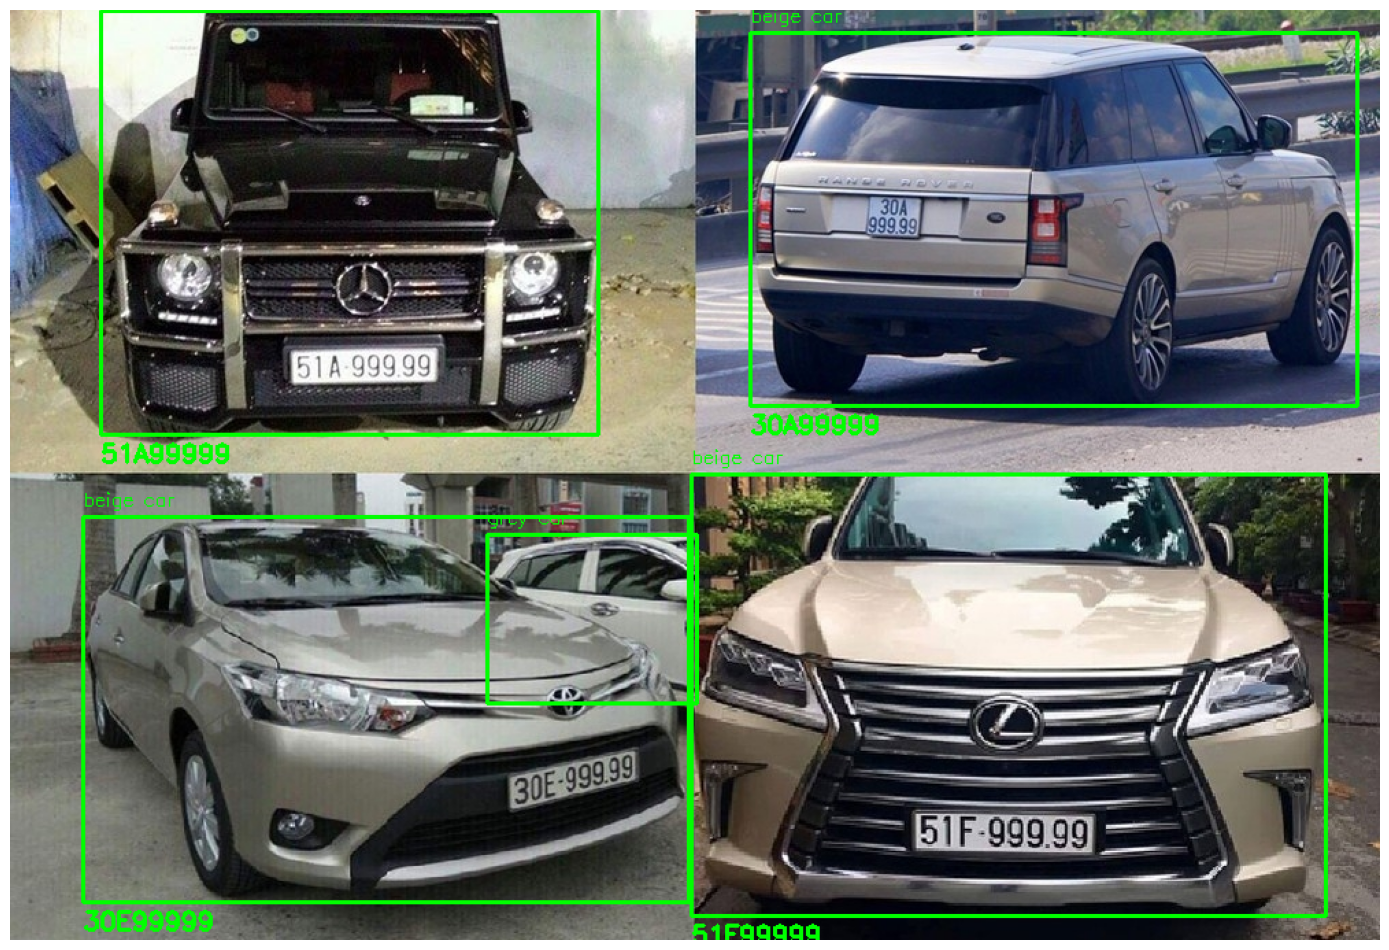

In [67]:
def draw_frame(img, vehicles, matched, all_violation_data):
    frame = img.copy()
    pm = {tuple(m[0]):m[4] for m in matched}
    for v in vehicles:
        bbox,vtype,color,conf,_,_ = v; x1,y1,x2,y2 = bbox
        hv = any(item[0]==bbox for item in all_violation_data)
        bc = (0,0,255) if hv else (0,255,0)
        cv2.rectangle(frame,(x1,y1),(x2,y2),bc,2)
        cv2.putText(frame,f"{color} {vtype}",(x1,y1-8),cv2.FONT_HERSHEY_SIMPLEX,0.45,bc,1)
        p = pm.get(tuple(bbox),'')
        if p: cv2.putText(frame,p,(x1,y2+20),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)
    for item in all_violation_data:
        for v2 in item[4]:
            vt,det,(vx1,vy1,vx2,vy2),vc = v2
            col = VIOLATION_COLORS.get(vt,(0,165,255))
            cv2.rectangle(frame,(vx1,vy1),(vx2,vy2),col,2)
            l = f"{vt} {vc*100:.1f}%"
            (tw,th),_ = cv2.getTextSize(l,cv2.FONT_HERSHEY_SIMPLEX,0.45,1)
            cv2.rectangle(frame,(vx1,vy1-th-4),(vx1+tw+4,vy1),col,-1)
            cv2.putText(frame,l,(vx1+2,vy1-2),cv2.FONT_HERSHEY_SIMPLEX,0.45,(255,255,255),1)
    return frame

uploaded = files.upload()
for fname in uploaded:
    img = cv2.imread(fname)
    if img is None: print(f'Cannot read: {fname}'); continue
    t0 = time.time()
    vehicles = detect_vehicles(img)
    plates = detect_plates(img)
    matched = match_plates_to_vehicles(vehicles, plates)
    violations = detect_violations_on_full_image(img)
    vm = assign_violations_to_vehicle(violations, vehicles)
    data = merge_violation_data(vm, vehicles, matched)
    result = draw_frame(img, vehicles, matched, data)
    print(f'{fname} ({img.shape[1]}x{img.shape[0]}) | {time.time()-t0:.2f}s')
    plt.figure(figsize=(14,10))
    plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
    plt.axis('off'); plt.tight_layout(); plt.show()
    cv2.imwrite(f'{DRIVE_BASE}/results/result_{fname}', result)
    if data:
        for item in data: print(f'   {item[2]} {item[1]} | Plate: {item[3] or "N/A"}'); [print(f'      - {v[0]}: {v[1]} ({v[3]*100:.1f}%)') for v in item[4]]

In [ ]:
import cv2
import json
import base64
from google.colab import output
from IPython.display import HTML, display

# Đường dẫn video của bạn
video_path = "/content/traffic_video.mp4"
cap = cv2.VideoCapture(video_path)
ret, first_frame = cap.read()
cap.release()

if ret:
    # Resize tạm thời để hiển thị vừa vặn trên màn hình Colab
    h, w, _ = first_frame.shape
    display_w = 800
    display_h = int(h * (display_w / w))
    img_resized = cv2.resize(first_frame, (display_w, display_h))
    _, buffer = cv2.imencode('.jpg', img_resized)
    b64_str = base64.b64encode(buffer).decode('utf-8')

    # Giao diện HTML + JavaScript hỗ trợ vẽ HÌNH THANG 3D (4 điểm)
    canvas_html = f"""
    <div style="background: #222; padding: 15px; border-radius: 8px; color: white; font-family: sans-serif; width: {display_w}px;">
        <h3 style="margin-top: 0; color: #00aaff;"> 🛠️ CÔNG CỤ XÁC ĐỊNH VÙNG HÌNH THANG 3D</h3>
        <p id="instruction" style="color: #ffca28; font-weight: bold; font-size: 15px;">👉 Bước 1: Click điểm 1 (DƯỚI - TRÁI) sát rìa đường gần camera</p>

        <div style="position: relative; display: inline-block;">
            <img id="roi_img" src="data:image/jpeg;base64,{b64_str}" width="{display_w}" height="{display_h}" style="cursor: crosshair; user-select: none; -webkit-user-drag: none;"/>
            <canvas id="roi_canvas" width="{display_w}" height="{display_h}" style="position: absolute; top: 0; left: 0; pointer-events: none;"></canvas>
        </div>
        <br/>
        <button id="reset_btn" style="margin-top:10px; padding:8px 15px; background:#dc3545; color:#fff; border:none; cursor:pointer; border-radius: 4px; margin-right: 10px; font-weight: bold;">Xóa vẽ lại</button>
        <button id="confirm_btn" style="margin-top:10px; padding:8px 15px; background:#28a745; color:#fff; border:none; cursor:pointer; border-radius: 4px; font-weight: bold;">Xác nhận vùng hình thang 3D</button>
    </div>

    <script>
        var points = []; // Lưu tối đa 4 điểm mốc

        var img = document.getElementById('roi_img');
        var canvas = document.getElementById('roi_canvas');
        var ctx = canvas.getContext('2d');
        var instruction = document.getElementById('instruction');

        var steps = [
            "👉 Bước 1: Click điểm 1 (DƯỚI - TRÁI) sát rìa đường gần camera",
            "👉 Bước 2: Click điểm 2 (DƯỚI - PHẢI) song song mép đường gần camera",
            "👉 Bước 3: Click điểm 3 (TRÊN - PHẢI) tiến lên gần sát ngã tư",
            "👉 Bước 4: Click điểm 4 (TRÊN - TRÁI) sát ngã tư để khép kín hình thang",
            "✅ Đã chọn đủ 4 điểm! Bấm 'Xác nhận vùng hình thang 3D' để lấy tọa độ."
        ];

        function redraw() {{
            ctx.clearRect(0, 0, canvas.width, canvas.height);

            // Cấu hình nét vẽ đa giác vùng (Xanh dương rực rỡ)
            ctx.fillStyle = "#00e5ff";
            ctx.strokeStyle = "#00e5ff";
            ctx.lineWidth = 3;

            // Vẽ các chấm điểm mốc tròn
            points.forEach((p, index) => {{
                ctx.beginPath();
                ctx.arc(p[0], p[1], 6, 0, 2 * Math.PI);
                ctx.fill();
                ctx.font = "bold 14px sans-serif";
                ctx.fillText(" " + (index + 1), p[0] + 8, p[1] + 5);
            }});

            // Vẽ các đường nối liên tiếp
            if (points.length > 0) {{
                ctx.beginPath();
                ctx.moveTo(points[0][0], points[0][1]);
                for (var i = 1; i < points.length; i++) {{
                    ctx.lineTo(points[i][0], points[i][1]);
                }}
                // Nếu đủ 4 điểm, tự động đóng kín hình thang
                if (points.length === 4) {{
                    ctx.closePath();
                    // Đổ màu mờ bên trong lòng hình thang để dễ kiểm tra độ phủ
                    ctx.fillStyle = "rgba(0, 229, 255, 0.2)";
                    ctx.fill();
                }}
                ctx.stroke();
            }}
        }}

        img.addEventListener('click', function(e) {{
            if (points.length >= 4) return;

            var rect = img.getBoundingClientRect();
            var x = e.clientX - rect.left;
            var y = e.clientY - rect.top;

            points.push([x, y]);

            if (points.length < 4) {{
                instruction.innerHTML = steps[points.length];
                instruction.style.color = "#ffca28";
            }} else {{
                instruction.innerHTML = steps[4];
                instruction.style.color = "#28a745";
            }}
            redraw();
        }});

        document.getElementById('reset_btn').addEventListener('click', function() {{
            points = [];
            instruction.innerHTML = steps[0];
            instruction.style.color = "#ffca28";
            redraw();
        }});

        document.getElementById('confirm_btn').addEventListener('click', function() {{
            if (points.length < 4) {{
                alert("Vui lòng click đủ 4 điểm theo đúng vòng tuần tự để tạo thành hình thang!");
                return;
            }}
            // Gửi dữ liệu mảng 4 điểm về Python xử lý scale gốc
            google.colab.kernel.invokeFunction('notebook.save_3d_points', [points, {w}, {display_w}, {h}, {display_h}], {{}});
        }});
    </script>
    """

    def save_3d_points(pts, orig_w, disp_w, orig_h, disp_h):
        scale_x = orig_w / disp_w
        scale_y = orig_h / disp_h

        # Quy đổi ngược từ pixel hiển thị về pixel video gốc 100%
        final_points = [[int(p[0] * scale_x), int(p[1] * scale_y)] for p in pts]

        print("\n" + "="*70)
        print(" CHỈ CẦN THAY THẾ CẢ ĐOẠN DƯỚI ĐÂY VÀO MỤC 1 TRONG CODE CHẠY VIDEO ")
        print("="*70)
        print("src_points = np.float32([")
        print(f"    {final_points[0]},   # 1. Duoi - Trai")
        print(f"    {final_points[1]},   # 2. Duoi - Phai")
        print(f"    {final_points[2]},   # 3. Tren - Phai")
        print(f"    {final_points[3]}    # 4. Tren - Trai")
        print("])")
        print("="*70 + "\n")

    output.register_callback('notebook.save_3d_points', save_3d_points)
    display(HTML(canvas_html))
else:
    print("Không thể trích xuất khung hình từ video, hãy kiểm tra lại biến video_path.")

In [71]:
import cv2
import numpy as np
import base64
from datetime import datetime
from collections import defaultdict
from ultralytics import YOLO
from IPython.display import display, HTML

# ==========================================
# 1. Cấu hình Mô hình và Ma trận Không gian 3D
# ==========================================
model = YOLO("/content/drive/MyDrive/TrafficAI/models/traffic_light.pt")
video_path = "/content/video_2.mp4"
cap = cv2.VideoCapture(video_path)

# CẤU HÌNH VÙNG GIÁM SÁT (HÌNH THANG 3D)
src_points = np.float32([
    [518, 705],    # 1. Duoi - Trai
    [1444, 804],   # 2. Duoi - Phai
    [1480, 602],   # 3. Tren - Phai
    [835, 600]     # 4. Tren - Trai
])

dst_points = np.float32([
    [0, 600],     # Dưới - Trái
    [400, 600],   # Dưới - Phải
    [400, 0],     # Trên - Phải
    [0, 0]        # Trên - Trái
])

M = cv2.getPerspectiveTransform(src_points, dst_points)
STOP_LINE_3D_Y = 400

# Lấy cấu hình từ widget
SPEED_LIMIT = CONFIG['speed_limit'].value
PIXELS_PER_METER = 10  # Tỷ lệ chuyển đổi pixel sang mét (cần hiệu chỉnh theo video thực tế)
FPS = 30  # Số khung hình/giây của video

def convert_to_3d_point(cx, cy, transform_matrix):
    point = np.array([[[cx, cy]]], dtype=np.float32)
    transformed_point = cv2.perspectiveTransform(point, transform_matrix)
    return transformed_point[0][0]

# ==========================================
# 2. Khởi tạo theo dõi vi phạm
# ==========================================
officially_violated_ids = set()  # Xe đã vi phạm (khung đỏ vĩnh viễn)
logged_violated_ids = set()  # Đã log vi phạm (chống trùng lặp)
violation_log = []  # Lưu lịch sử vi phạm

# Bộ nhớ theo dõi tốc độ
vehicle_tracks = defaultdict(list)  # {track_id: [(frame_num, x_3d, y_3d, timestamp)]}
speed_violation_ids = set()  # Xe vi phạm tốc độ

# Bộ đếm đèn đỏ
red_light_counter = 0
RED_LIGHT_BUFFER_FRAMES = 30

# ==========================================
# 3. Khởi tạo giao diện HTML
# ==========================================
ui_html = """
<div style="display: flex; flex-direction: column; align-items: center; background: #1e1e1e; padding: 15px; border-radius: 8px; width: 870px;">
    <div id="video_container">
        <img id="video_frame" src="" width="850" style="border-radius: 4px;"/>
    </div>
    <div style="width: 850px; margin-top: 15px;">
        <h4 style="color: #00aaff; margin: 5px 0; font-family: sans-serif;"> HỆ THỐNG GIÁM SÁT KHÔNG GIAN 3D (BIRD'S EYE VIEW):</h4>
        <div id="log_container" style="background: #000; color: #00ff00; font-family: monospace; height: 200px; overflow-y: scroll; padding: 10px; border: 1px solid #333; border-radius: 4px; text-align: left; font-size: 13px; line-height: 1.6;">
            [Đã thiết lập hệ thống ghi nhận vi phạm độc lập - Cảnh báo 1 lần duy nhất]...<br/>
        </div>
    </div>
</div>

<script>
    function appendViolationLog(text) {
        var logDiv = document.getElementById('log_container');
        logDiv.innerHTML += text + "<br/>";
        logDiv.scrollTop = logDiv.scrollHeight;
    }
    function updateVideoFrame(base64_img) {
        document.getElementById('video_frame').src = "data:image/jpeg;base64," + base64_img;
    }
</script>
"""

display_handle = display(HTML(ui_html), display_id=True)

frame_count = 0

print(f"🚀 Bắt đầu xử lý video: {video_path}")
print(f"📊 Cấu hình: Tốc độ tối đa = {SPEED_LIMIT} km/h, FPS = {FPS}")
print(f"🎯 Phát hiện vi phạm: Vượt đèn đỏ, Không đội mũ, Dùng điện thoại, Quá 2 người, Vượt tốc độ")
print(f"🎨 Nhận dạng: Biển số xe, Màu sắc xe\n")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    current_time = datetime.now().strftime("%H:%M:%S")

    # Tính toán vạch dừng ảo bằng ma trận nghịch đảo
    line_3d_pts = np.array([[[0, STOP_LINE_3D_Y]], [[400, STOP_LINE_3D_Y]]], dtype=np.float32)
    M_inv = np.linalg.inv(M)
    line_2d_pts = cv2.perspectiveTransform(line_3d_pts, M_inv)
    left_x, left_y = map(int, line_2d_pts[0][0])
    right_x, right_y = map(int, line_2d_pts[1][0])

    # Vẽ vùng hình thang kiểm soát và vạch dừng (nếu bật show_zones)
    if CONFIG['show_zones'].value:
        pts = src_points.astype(np.int32)
        cv2.polylines(frame, [pts], True, (255, 255, 0), 2)
        cv2.line(frame, (left_x, left_y), (right_x, right_y), (0, 152, 255), 4)

    # Tracking YOLO
    results = model.track(source=frame, conf=0.20, persist=True, verbose=False)

    # 🚦 LOGIC LỌC NHẤP NHÁY ĐÈN ĐỎ (chỉ khi bật)
    yolo_detected_red = False
    if CONFIG['enable_red_light'].value:
        for r in results:
            if r.boxes is None: continue
            for box in r.boxes:
                cls = int(box.cls[0])
                name = model.names[cls]
                if "trafficLight" in name and "red" in name.lower():
                    yolo_detected_red = True
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)

    if yolo_detected_red:
        red_light_counter = RED_LIGHT_BUFFER_FRAMES
    else:
        if red_light_counter > 0:
            red_light_counter -= 1

    is_red_light_active = (red_light_counter > 0) if CONFIG['enable_red_light'].value else False

    # 🎨 NHẬN DẠNG BIỂN SỐ VÀ MÀU XE
    vehicles = []
    for r in results:
        if r.boxes is None: continue
        for box in r.boxes:
            cls = int(box.cls[0])
            name = model.names[cls]
            if "trafficLight" in name: continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cid = int(box.cls[0])
            vt = VEHICLE_CLASSES.get(cid,'vehicle')

            # Phát hiện màu xe
            color = 'unknown'
            crop = frame[max(0,y1):min(frame.shape[0],y2), max(0,x1):min(frame.shape[1],x2)]
            if color_model and crop.size>0:
                try:
                    cr = color_model.predict(crop,device=DEVICE,verbose=False)[0]
                    if hasattr(cr,'probs') and cr.probs:
                        color = COLOR_NAMES[cr.probs.top1] if cr.probs.top1<len(COLOR_NAMES) else 'unknown'
                    elif hasattr(cr,'boxes') and cr.boxes and len(cr.boxes)>0:
                        color = COLOR_NAMES[int(cr.boxes.cls[0])] if int(cr.boxes.cls[0])<len(COLOR_NAMES) else 'unknown'
                except: pass

            vehicles.append(((x1,y1,x2,y2),vt,color,box.conf[0].item(),crop,None))

    # Phát hiện biển số
    plates = detect_plates(frame)
    matched = match_plates_to_vehicles(vehicles, plates)

    # Vẽ thông tin xe (màu + biển số)
    plate_map = {tuple(m[0]):m[4] for m in matched}
    for v in vehicles:
        bbox,vtype,color,conf,_,_ = v; x1,y1,x2,y2 = bbox

        # Vẽ màu xe
        cv2.putText(frame,f"{color} {vtype}",(x1,y1-8),cv2.FONT_HERSHEY_SIMPLEX,0.45,(0,255,0),1)

        # Vẽ biển số nếu có
        p = plate_map.get(tuple(bbox),'')
        if p:
            cv2.putText(frame,p,(x1,y2+20),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)

    # 🛵 PHÁT HIỆN VI PHẠM: KHÔNG ĐỘI MŨ, DÙNG ĐIỆN THOẠI, QUÁ 2 NGƯỜI (chỉ khi bật)
    frame_violations = []
    if CONFIG['enable_violation_detection'].value and helmet_model is not None:
        frame_violations = detect_violations_on_full_image(frame)

        # Gán vi phạm cho từng xe và log
        if frame_violations:
            for viol in frame_violations:
                v_type = viol['type']
                v_bbox = viol['bbox']
                v_conf = viol['conf']
                v_details = viol['details']

                # Tìm xe máy gần nhất với vi phạm
                best_vehicle = None
                best_dist = float('inf')
                for vr in vehicles:
                    vb,vt = vr[0],vr[1]
                    if vt!='motorcycle': continue
                    vx1,vy1,vx2,vy2 = vb
                    vbx1,vby1,vbx2,vby2 = v_bbox
                    v_cx = (vx1 + vx2) / 2
                    v_cy = vy2

                    # Tính khoảng cách giữa vi phạm và xe
                    viol_cx = (v_bbox[0] + v_bbox[2]) / 2
                    viol_cy = v_bbox[3]
                    dist = np.sqrt((v_cx - viol_cx)**2 + (v_cy - viol_cy)**2)

                    if dist < best_dist:
                        best_dist = dist
                        best_vehicle = vr

                # Nếu tìm thấy xe gần và chưa bị phạt
                if best_vehicle is not None:
                    track_id = 0  # Sử dụng track_id từ results nếu có
                    for r in results:
                        if r.boxes is None: continue
                        for box in r.boxes:
                            if int(box.cls[0]) == 3:  # motorcycle
                                vx1,vy1,vx2,vy2 = map(int,box.xyxy[0])
                                if abs(vx1 - best_vehicle[0][0]) < 10:
                                    track_id = int(box.id[0]) if box.id is not None else 0
                                    break

                    unique_key = f"motorcycle_{track_id}"

                    # Kiểm tra xem đã log chưa (chống trùng lặp)
                    log_key = f"{v_type}_{track_id}"
                    if log_key not in logged_violated_ids:
                        logged_violated_ids.add(log_key)

                        # Thêm vào log
                        log_text = f"<span style='color:#ff6600;'>[{current_time}] ⚠️ {v_details.upper()}: Xe <b>{unique_key.upper()}</b> ({v_conf*100:.1f}%)</span>"
                        display(HTML(f"<script>appendViolationLog(\"{log_text}\");</script>"), display_id="log_agent")
                        violation_log.append({
                            'time': current_time,
                            'type': v_type,
                            'vehicle': unique_key,
                            'confidence': v_conf
                        })

                # Vẽ bounding box cho vi phạm
                cv2.rectangle(frame, (v_bbox[0], v_bbox[1]), (v_bbox[2], v_bbox[3]), VIOLATION_COLORS.get(v_type, (0, 165, 255)), 2)
                label = f"{v_type}: {v_conf*100:.1f}%"
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
                cv2.rectangle(frame, (v_bbox[0], v_bbox[1]-th-4), (v_bbox[0]+tw+4, v_bbox[1]), VIOLATION_COLORS.get(v_type, (0, 165, 255)), -1)
                cv2.putText(frame, label, (v_bbox[0]+2, v_bbox[1]-2), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

    # 🚗 XỬ LÝ TỪNG XE
    for r in results:
        if r.boxes is None: continue
        for box in r.boxes:
            cls = int(box.cls[0])
            name = model.names[cls]
            if "trafficLight" in name: continue

            track_id = int(box.id[0]) if box.id is not None else 0
            unique_key = f"{name}_{track_id}"

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cx = int((x1 + x2) / 2)
            cy_tail = y2

            # Chuyển đổi tọa độ sang 3D Bird's Eye View
            x_3d, y_3d = convert_to_3d_point(cx, cy_tail, M)

            # Kiểm tra xe có nằm trong lòng hình thang hay không
            is_inside_zone = (0 <= x_3d <= 400) and (0 <= y_3d <= 600)
            is_past_line_3d = is_inside_zone and (y_3d < STOP_LINE_3D_Y)

            # 📍 THEO DÕI TỐC ĐỘ (chỉ khi bật)
            if CONFIG['enable_speed_violation'].value and is_inside_zone:
                vehicle_tracks[track_id].append((frame_count, x_3d, y_3d, current_time))

                # Tính tốc độ nếu có đủ dữ liệu (kiểm tra 15 khung trước đó ~ 0.5 giây)
                if len(vehicle_tracks[track_id]) >= 15:
                    recent_frames = vehicle_tracks[track_id][-15:]
                    first_frame_num, first_x, first_y, _ = recent_frames[0]
                    last_frame_num, last_x, last_y, _ = recent_frames[-1]

                    # Khoảng cách di chuyển (pixel)
                    distance_pixels = np.sqrt((last_x - first_x)**2 + (last_y - first_y)**2)
                    distance_meters = distance_pixels / PIXELS_PER_METER

                    # Thời gian di chuyển (giây)
                    time_elapsed = (last_frame_num - first_frame_num) / FPS

                    if time_elapsed > 0:
                        speed_kmh = (distance_meters / time_elapsed) * 3.6  # Chuyển m/s sang km/h

                        # Kiểm tra vi phạm tốc độ
                        if speed_kmh > SPEED_LIMIT and track_id not in speed_violation_ids:
                            speed_violation_ids.add(track_id)
                            log_text = f"<span style='color:#ff00ff;'>[{current_time}] ⚡ TỐC ĐỘ: Xe <b>{unique_key.upper()}</b> chạy {speed_kmh:.1f} km/h (Giới hạn {SPEED_LIMIT} km/h)!</span>"
                            display(HTML(f"<script>appendViolationLog(\"{log_text}\");</script>"), display_id="log_agent")
                            violation_log.append({
                                'time': current_time,
                                'type': 'SPEED_VIOLATION',
                                'vehicle': unique_key,
                                'speed': speed_kmh,
                                'limit': SPEED_LIMIT
                            })

            color = (0, 255, 0)
            label = unique_key

            # Nếu xe này ĐÃ TỪNG bị bắt vi phạm trước đó, ghim cứng khung đỏ (Dù đèn có xanh lại hay xe đi đâu)
            if unique_key in officially_violated_ids:
                color = (0, 0, 255)
                label = f"VI PHAM 3D! {unique_key.upper()}"
                cv2.rectangle(frame, (x1, y1 - 20), (x1 + 180, y1), (0, 0, 255), -1)
                cv2.putText(frame, label, (x1 + 5, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

            # Nếu đang đèn đỏ và xe thực sự mới vượt vạch lần đầu
            elif CONFIG['enable_red_light'].value and is_red_light_active and is_past_line_3d:
                officially_violated_ids.add(unique_key)  # Đưa vào danh sách đen để ghim khung đỏ

                color = (0, 0, 255)
                label = f"VI PHAM 3D! {unique_key.upper()}"
                cv2.rectangle(frame, (x1, y1 - 20), (x1 + 180, y1), (0, 0, 255), -1)
                cv2.putText(frame, label, (x1 + 5, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

                # KIỂM TRA: Chỉ bắn log lên màn hình đúng 1 lần duy nhất cho ID này
                if unique_key not in logged_violated_ids:
                    logged_violated_ids.add(unique_key)
                    log_text = f"<span style='color:#ff4d4d;'>[{current_time}] 🔴 HỆ THỐNG 3D: Xe <b>{unique_key.upper()}</b> vượt ranh giới 3D khi đèn đỏ!</span>"
                    display(HTML(f"<script>appendViolationLog(\"{log_text}\");</script>"), display_id="log_agent")
                    violation_log.append({
                        'time': current_time,
                        'type': 'RED_LIGHT',
                        'vehicle': unique_key
                    })

            # Đèn đỏ nhưng xe chưa vượt vạch
            elif is_red_light_active:
                color = (0, 255, 255)
                label = f"DUNG CHO: {unique_key}"
                cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

            # Hiển thị tốc độ nếu có (chỉ khi bật speed violation)
            if CONFIG['enable_speed_violation'].value and track_id in vehicle_tracks and len(vehicle_tracks[track_id]) >= 15:
                recent = vehicle_tracks[track_id][-15:]
                first_frame_num, first_x, first_y, _ = recent[0]
                last_frame_num, last_x, last_y, _ = recent[-1]
                distance_pixels = np.sqrt((last_x - first_x)**2 + (last_y - first_y)**2)
                distance_meters = distance_pixels / PIXELS_PER_METER
                time_elapsed = (last_frame_num - first_frame_num) / FPS
                if time_elapsed > 0:
                    speed_kmh = (distance_meters / time_elapsed) * 3.6
                    speed_color = (0, 255, 0) if speed_kmh <= SPEED_LIMIT else (128, 0, 128)
                    cv2.putText(frame, f"{speed_kmh:.1f} km/h", (x1, y2 + 35), cv2.FONT_HERSHEY_SIMPLEX, 0.5, speed_color, 2)

            # Đèn xanh/vàng bình thường
            else:
                cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

    # Hiển thị trạng thái hệ thống
    status_text = "HE THONG 3D: DANG DEN DO" if is_red_light_active else "HE THONG 3D: DEN XANH / VANG"
    status_color = (0, 0, 255) if is_red_light_active else (0, 255, 0)
    cv2.putText(frame, status_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2)

    # Hiển thị thông tin tốc độ (chỉ khi bật)
    if CONFIG['enable_speed_violation'].value:
        cv2.putText(frame, f"Toc do toi da: {SPEED_LIMIT} km/h", (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (128, 0, 128), 2)

    # Hiển thị số khung hình
    cv2.putText(frame, f"Frame: {frame_count}", (20, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Render kết quả lên màn hình Colab
    _, buffer = cv2.imencode('.jpg', frame)
    b64_str = base64.b64encode(buffer).decode('utf-8')
    display(HTML(f"<script>updateVideoFrame('{b64_str}');</script>"), display_id="video_agent")

cap.release()

# ==========================================
# 4. Tổng hợp kết quả vi phạm
# ==========================================
print("\n" + "="*70)
print("📊 TỔNG HỢP VI PHẠM")
print("="*70)
if CONFIG['enable_red_light'].value:
    print(f"🔴 Vượt đèn đỏ: {len([v for v in violation_log if v['type'] == 'RED_LIGHT'])} xe")
if CONFIG['enable_speed_violation'].value:
    print(f"⚡ Vượt tốc độ: {len([v for v in violation_log if v['type'] == 'SPEED_VIOLATION'])} xe")
if CONFIG['enable_violation_detection'].value:
    print(f"⭕ Không đội mũ: {len([v for v in violation_log if v['type'] == 'WITHOUT_HELMET'])} xe")
    print(f"📱 Dùng điện thoại: {len([v for v in violation_log if v['type'] == 'USING_MOBILE'])} xe")
    print(f"👥 Quá 2 người: {len([v for v in violation_log if v['type'] == 'MORE_THAN_TWO_PERSONS'])} xe")
print("="*70)
print(f"\n📋 Chi tiết vi phạm:")
for i, viol in enumerate(violation_log, 1):
    print(f"{i}. [{viol['time']}] {viol['type']}: {viol['vehicle']}", end='')
    if 'speed' in viol:
        print(f" - Tốc độ: {viol['speed']:.1f} km/h")
    else:
        print()

# Lưu log ra file
log_file = f'{DRIVE_BASE}/results/violation_log_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
with open(log_file, 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("TỔNG HỢP VI PHẠM GIAO THÔNG\n")
    f.write("="*70 + "\n\n")
    f.write(f"Tổng số vi phạm: {len(violation_log)}\n\n")
    for viol in violation_log:
        f.write(f"[{viol['time']}] {viol['type']}: {viol['vehicle']}")
        if 'speed' in viol:
            f.write(f" - Tốc độ: {viol['speed']:.1f} km/h\n")
        else:
            f.write("\n")
print(f"\n💾 Log đã được lưu tại: {log_file}")

🚀 Bắt đầu xử lý video: /content/video_2.mp4
📊 Cấu hình: Tốc độ tối đa = 60 km/h, FPS = 30
🎯 Phát hiện vi phạm: Vượt đèn đỏ, Không đội mũ, Dùng điện thoại, Quá 2 người, Vượt tốc độ
🎨 Nhận dạng: Biển số xe, Màu sắc xe


0: 384x640 1 license-plate, 6.2ms
Speed: 3.2ms preprocess, 6.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)



0: 384x640 1 license-plate, 8.3ms
Speed: 2.8ms preprocess, 8.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license-plate, 8.6ms
Speed: 3.9ms preprocess, 8.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license-plate, 10.6ms
Speed: 2.8ms preprocess, 10.6ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license-plates, 11.5ms
Speed: 2.4ms preprocess, 11.5ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license-plate, 9.1ms
Speed: 2.6ms preprocess, 9.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 7.4ms
Speed: 4.3ms preprocess, 7.4ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 11.7ms
Speed: 6.8ms preprocess, 11.7ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 13.1ms
Speed: 3.1ms preprocess, 13.1ms inferenc


0: 384x640 (no detections), 9.2ms
Speed: 2.8ms preprocess, 9.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license-plate, 8.6ms
Speed: 2.6ms preprocess, 8.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license-plate, 9.6ms
Speed: 2.6ms preprocess, 9.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license-plate, 8.5ms
Speed: 2.5ms preprocess, 8.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license-plates, 9.4ms
Speed: 4.1ms preprocess, 9.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license-plate, 9.8ms
Speed: 2.5ms preprocess, 9.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license-plate, 11.9ms
Speed: 2.6ms preprocess, 11.9ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license-plate, 8.4ms
Speed: 3.3ms preprocess, 8.4ms inference, 1.2